In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph , START , END


In [2]:
class GreetState(BaseModel):
    message:str = ""

graph = StateGraph(GreetState)

def greet(state : GreetState):
    state.message = f'{state.message} ! i am good'
    return state 

def special(state : GreetState):
    state.message = state.message.capitalize()
    return state 


In [3]:
graph.add_node("greet"  , greet)
graph.add_node("special" , special)

In [4]:
graph.add_edge(START , "greet")
graph.add_edge("greet" , "special")
graph.add_edge("special" , END)

final_graph = graph.compile()


In [5]:
res = final_graph.invoke(GreetState(message= "You are handsome "))
print(res)

{'message': 'You are handsome  ! i am good'}


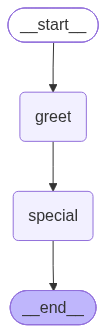

In [6]:
from IPython.display import Image 

Image(final_graph.get_graph().draw_mermaid_png())

In [8]:
# langgraph agent model 

from langchain_groq import ChatGroq 
from langgraph.graph import StateGraph , START , END 
from pydantic import BaseModel 
from typing import Annotated  
from langgraph.checkpoint.memory import InMemorySaver 
from langgraph.graph.message import add_messages

In [9]:
class ChatState(BaseModel):
    messages:Annotated[list , add_messages]

llm = ChatGroq(model = "openai/gpt-oss-20b")
def chatbot(state:ChatState) ->  ChatState  : 
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state


In [10]:
graph = StateGraph(ChatState)
graph.add_node("chatbot" ,  chatbot)
graph.add_edge(START , "chatbot")
graph.add_edge("chatbot" , END)

memory = InMemorySaver()
final_graph = graph.compile(checkpointer=memory) 

In [13]:
from langchain_core.runnables.config import RunnableConfig

while(True):
    user = input("user : ")
    if user == "bye":
        break
    query = ChatState(messages=[{"role": "user", "content": user}])
    config = {"configurable" : {"thread_id" : "my_bot_1"}}
    config: RunnableConfig = {"configurable": {"thread_id": "my_bot_1"}}
    res = final_graph.invoke(query, config=config)
    print("Ai : - " ,res["messages"][-1].content)

Ai : -  Hi there! How can I help you today?
Ai : -  As of the most recent information available (up to mid‑2024), **Narendra Modi** is the serving Prime Minister of India. He has been in office since May 26, 2014, having been re‑elected in the 2019 general elections.

> **Quick note:**  
> • The next general election in India was scheduled for 2024, but the official results and any subsequent change in leadership were not yet confirmed in the data available to me.  
> • If you need the absolute latest update (e.g., after the 2024 elections), I recommend checking a reliable news source or the official Government of India website.

Let me know if you’d like more details about Modi’s tenure, the election timeline, or anything else!
Ai : -  Narendra Modi was born on **17 September 1950**.  
As of today, **4 October 2026**, he is **76 years old** (he turned 76 on 17 September 2026).
Ai : -  Hi Pradeep! 🚀  
Building new skills is a journey that can be both exciting and rewarding. Below is a 